In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import seaborn as sns
from plotly.subplots import make_subplots

from utils.figures_utils import *


In [2]:
sns.set_theme(style="whitegrid")

TOOL_ORDER = [
    "methylseg_wgbs",
    "methylseg_hm450k",
    "methylseekr",
    "dnmtools",
    "dnmtools_array",
    "dnmtools_pmr",
    "mmseekr",
    "methylasso",
]

TOOL_LABELS = {
    "methylseg_wgbs": "MethylSeg WGBS",
    "methylseg_hm450k": "MethylSeg HM450K",
    "methylseekr": "MethylSeekR",
    "dnmtools": "DNMTools",
    "dnmtools_array": "DNMTools Array",
    "dnmtools_pmr": "DNMTools PMR",
    "mmseekr": "MMSeekR",
    "methylasso": "MethylLasso",
}

RESOLUTION_MAP = {
    "methylseg_wgbs": "WGBS",
    "methylseg_hm450k": "HM450K",
    "methylseekr": "WGBS",
    "dnmtools": "WGBS",
    "dnmtools_array": "HM450K",
    "dnmtools_pmr": "WGBS",
    "mmseekr": "WGBS",
    "methylasso": "WGBS",
}

RUN_TOOL_NAME_MAP = {
    "DNMTools_Array_PMD": "dnmtools_array",
    "DNMTools_PMD": "dnmtools",
    "DNMTools_PMR": "dnmtools_pmr",
    "MethylSeekR": "methylseekr",
    "MethylSeg_HM450K": "methylseg_hm450k",
    "MethylSeg_WGBS": "methylseg_wgbs",
    "methylasso": "methylasso",
    "mmseekr": "mmseekr",
}

REGION_TOOL_NAME_MAP = {
    "dnmtools": "dnmtools",
    "dnmtools_array": "dnmtools_array",
    "dnmtools_pmr": "dnmtools_pmr",
    "methylasso": "methylasso",
    "methylseekr": "methylseekr",
    "methylseg_hm450k": "methylseg_hm450k",
    "methylseg_wgbs": "methylseg_wgbs",
    "mmseekr": "mmseekr",
}

FIGSIZE_MEMORY = (11, 6)
FIGSIZE_RUNTIME = (11, 6)
FIGSIZE_PMD = (16, 6)
DPI = 300

MEMORY_TITLE = "Peak Memory Usage Across Region Calling Tools"
RUNTIME_TITLE = "Runtime Across Region Calling Tools"
TABLE_TITLE = "Region Calling Summary by Tool"
PMD_METH_TITLE = "Average Methylation by Tool"
PMD_INTERMEDIATE_TITLE = "Intermediate CpGs by Tool"

SAVE_FIGURES = False
SAVE_DIR = OUT_DIR / "region_calling_figures"


In [3]:
def normalize_run_tool_name(tool_name: str) -> str:
    return RUN_TOOL_NAME_MAP.get(str(tool_name), str(tool_name))


def normalize_region_tool_name(tool_name: str) -> str:
    return REGION_TOOL_NAME_MAP.get(str(tool_name), str(tool_name))


def ordered_tool_labels() -> list[str]:
    return [TOOL_LABELS[tool] for tool in TOOL_ORDER]


def apply_tool_order(df: pd.DataFrame, tool_col: str = "tool_normalized") -> pd.DataFrame:
    out_df = df.copy()
    out_df[tool_col] = pd.Categorical(out_df[tool_col], categories=TOOL_ORDER, ordered=True)
    out_df = out_df.dropna(subset=[tool_col]).sort_values(tool_col).reset_index(drop=True)
    return out_df


def add_tool_labels(df: pd.DataFrame, tool_col: str = "tool_normalized") -> pd.DataFrame:
    out_df = df.copy()
    out_df["tool_label"] = out_df[tool_col].map(TOOL_LABELS)
    out_df["tool_label"] = pd.Categorical(
        out_df["tool_label"],
        categories=ordered_tool_labels(),
        ordered=True,
    )
    return out_df


def savefig_if_enabled(fig: plt.Figure, filename: str) -> None:
    if not SAVE_FIGURES:
        return
    SAVE_DIR.mkdir(parents=True, exist_ok=True)
    fig.savefig(SAVE_DIR / filename, dpi=DPI, bbox_inches="tight")


In [4]:
run_stats_df = get_run_stats_df().copy()
run_stats_df["tool_normalized"] = run_stats_df["tool_name"].map(normalize_run_tool_name)
run_stats_df["mem_peak_gb"] = pd.to_numeric(run_stats_df["mem_peak_mb"], errors="coerce") / 1024.0
run_stats_df["runtime_min"] = pd.to_numeric(run_stats_df["runtime_sec"], errors="coerce") / 60.0
run_stats_df = apply_tool_order(run_stats_df)
run_stats_df = add_tool_labels(run_stats_df)

run_stats_summary_df = (
    run_stats_df.groupby("tool_normalized", observed=True)
    .agg(
        n_samples=("sample_id", "nunique"),
        avg_mem_peak_gb=("mem_peak_gb", "mean"),
        avg_runtime_min=("runtime_min", "mean"),
    )
    .reset_index()
)
run_stats_summary_df["Resolution"] = run_stats_summary_df["tool_normalized"].map(RESOLUTION_MAP)
run_stats_summary_df["Tool"] = run_stats_summary_df["tool_normalized"].map(TOOL_LABELS)
run_stats_summary_df = run_stats_summary_df[[
    "Tool",
    "Resolution",
    "avg_mem_peak_gb",
    "avg_runtime_min",
]].rename(columns={
    "avg_mem_peak_gb": "Avg Peak Memory (GB)",
    "avg_runtime_min": "Avg Runtime (min)",
})
run_stats_summary_df = run_stats_summary_df.round({
    "Avg Peak Memory (GB)": 2,
    "Avg Runtime (min)": 2,
})

run_stats_summary_fig = plot_summary_table(
    run_stats_summary_df,
    "Aggregate Run Stats Across Samples",
)
run_stats_summary_fig


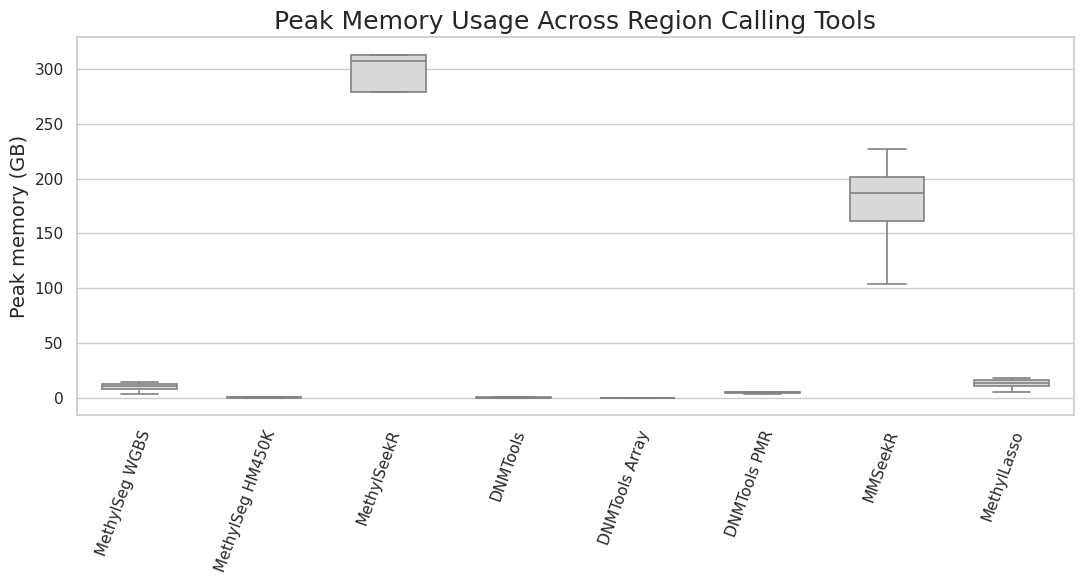

In [5]:
fig, ax = plt.subplots(figsize=FIGSIZE_MEMORY)
draw_boxplot(ax, run_stats_df, "mem_peak_gb", MEMORY_TITLE, "Peak memory (GB)")
fig.tight_layout()
savefig_if_enabled(fig, "memory_box.png")
plt.show()


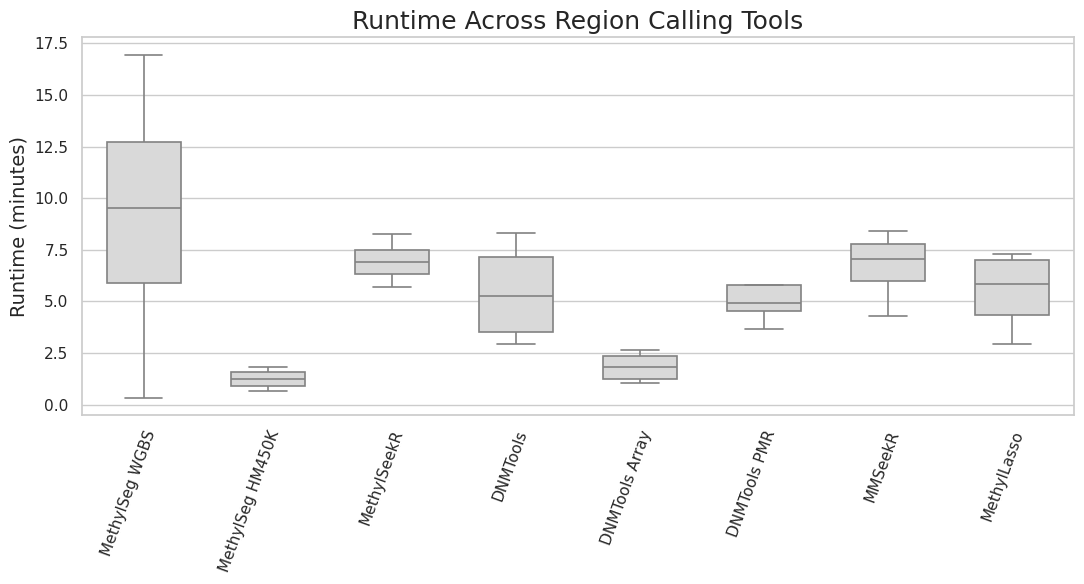

In [6]:
fig, ax = plt.subplots(figsize=FIGSIZE_RUNTIME)
draw_boxplot(ax, run_stats_df, "runtime_min", RUNTIME_TITLE, "Runtime (minutes)")
fig.tight_layout()
savefig_if_enabled(fig, "runtime_box.png")
plt.show()


In [7]:
region_stats_df = get_region_stats_df().copy()
region_stats_df["tool_normalized"] = region_stats_df["tool"].map(normalize_region_tool_name)
region_stats_df = apply_tool_order(region_stats_df)

summary_table_df = (
    region_stats_df.groupby("tool_normalized", observed=True)
    .agg(
        avg_total_regions_called=("n_regions", "mean"),
        avg_median_region_length=("median_length", "mean"),
        avg_genome_coverage_pct=("genome_coverage_pct", "mean"),
    )
    .reset_index()
)
summary_table_df["Resolution"] = summary_table_df["tool_normalized"].map(RESOLUTION_MAP)
summary_table_df["Tool"] = summary_table_df["tool_normalized"].map(TOOL_LABELS)
summary_table_df = summary_table_df[[
    "Tool",
    "Resolution",
    "avg_total_regions_called",
    "avg_median_region_length",
    "avg_genome_coverage_pct",
]].rename(columns={
    "avg_total_regions_called": "Avg Total Regions Called",
    "avg_median_region_length": "Avg Median Region Length",
    "avg_genome_coverage_pct": "Avg Genome Coverage (%)",
})
summary_table_df = summary_table_df.round({
    "Avg Total Regions Called": 1,
    "Avg Median Region Length": 1,
    "Avg Genome Coverage (%)": 2,
})

summary_table_fig = plot_summary_table(summary_table_df, TABLE_TITLE)
summary_table_fig


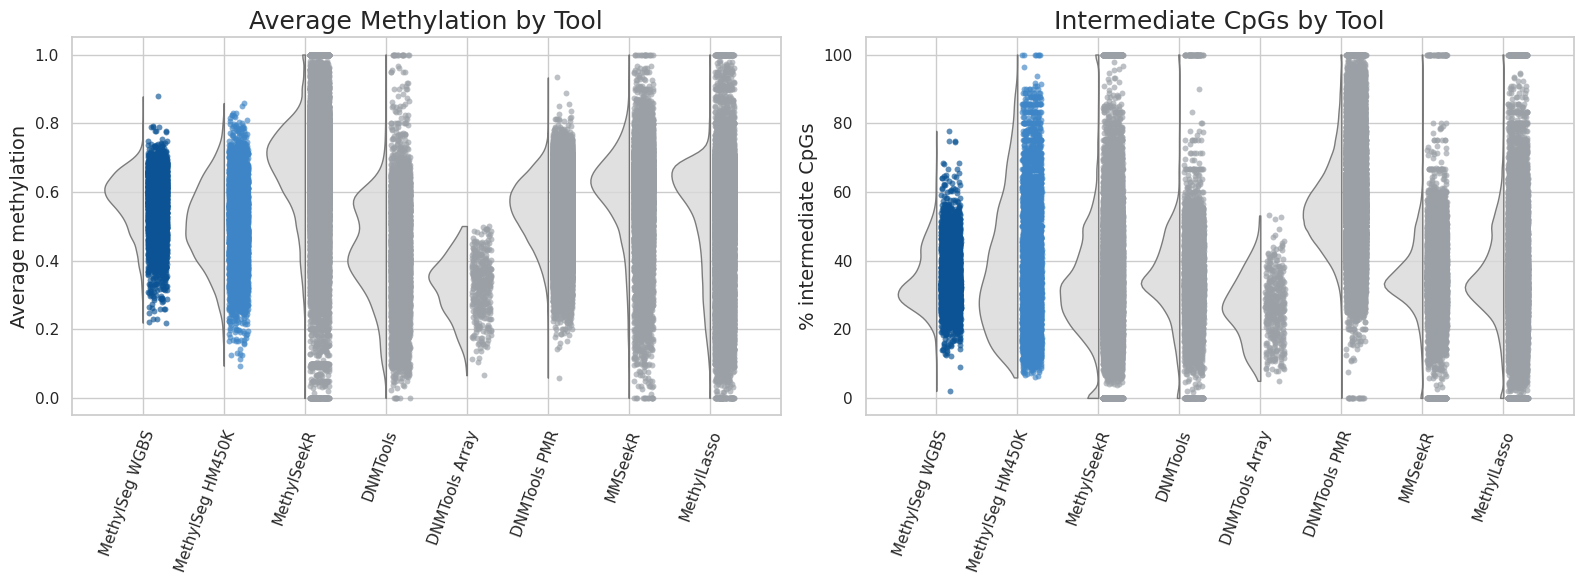

In [8]:
region_context_df = get_region_context_df().copy()
region_context_df["tool_normalized"] = region_context_df["tool"].map(normalize_region_tool_name)
region_context_df = apply_tool_order(region_context_df)
region_context_df = add_tool_labels(region_context_df)

fig, axes = plt.subplots(1, 2, figsize=FIGSIZE_PMD, sharex=True)

draw_violin_with_points(axes[0], region_context_df, "mean_meth", PMD_METH_TITLE, "Average methylation")

draw_violin_with_points(axes[1], region_context_df, "pct_intermediate", PMD_INTERMEDIATE_TITLE, "% intermediate CpGs")

fig.tight_layout()
savefig_if_enabled(fig, "pmd_methylation_intermediate_violins.png")
plt.show()


In [23]:
jaccard_matrix = load_jaccard_matrix(wgbs_cancer_samples()[-1])
pct_covered_matrix = load_pct_cover_matrix(wgbs_cancer_samples()[-1])

In [24]:
COMPARISON_TOOL_LABELS = {
    "methylseg": "MethylSeg WGBS",
    "methylseg_wgbs": "MethylSeg WGBS",
    "methylseg_hm450k": "MethylSeg HM450K",
    "methylseekr": "MethylSeekR",
    "dnmtools": "DNMTools",
    "dnmtools_array": "DNMTools Array",
    "dnmtools_pmr": "DNMTools PMR",
    "mmseekr": "MMSeekR",
    "methyl_lasso": "MethylLasso",
    "methylasso": "MethylLasso",
}

def relabel_comparison_matrix(matrix_df: pd.DataFrame) -> pd.DataFrame:
    display_df = matrix_df.copy()
    display_labels = [COMPARISON_TOOL_LABELS.get(tool, tool) for tool in display_df.index]
    display_df.index = display_labels
    display_df.columns = display_labels
    return display_df

plot_jaccard_matrix = relabel_comparison_matrix(jaccard_matrix).round(4)
plot_pct_covered_matrix = relabel_comparison_matrix((pct_covered_matrix * 100.0).round(4))
plot_pct_not_covered_matrix = (100.0 - plot_pct_covered_matrix).round(4)

white_red = [
    [0.0, "white"],
    [1.0, "red"],
]

heatmap_names = plot_jaccard_matrix.index.tolist()

fig = make_subplots(
    rows=3,
    cols=1,
    subplot_titles=(
        "Percent of A covered by B (%)",
        "Percent of A NOT covered by B (%)",
        "Jaccard index (intersection / union)",
    ),
)

fig.add_trace(
    go.Heatmap(
        z=plot_pct_covered_matrix.values,
        x=heatmap_names,
        y=heatmap_names,
        zmin=0,
        zmax=100,
        colorscale=white_red,
        colorbar=dict(title="% covered", lenmode="fraction", len=0.25, y=0.85),
        hovertemplate="A: %{y}<br>B: %{x}<br>% covered: %{z:.2f}%<extra></extra>",
    ),
    row=1,
    col=1,
)

fig.add_trace(
    go.Heatmap(
        z=plot_pct_not_covered_matrix.values,
        x=heatmap_names,
        y=heatmap_names,
        zmin=0,
        zmax=100,
        colorscale=white_red,
        colorbar=dict(title="% not covered", lenmode="fraction", len=0.25, y=0.52),
        hovertemplate="A: %{y}<br>B: %{x}<br>% not covered: %{z:.2f}%<extra></extra>",
    ),
    row=2,
    col=1,
)

fig.add_trace(
    go.Heatmap(
        z=plot_jaccard_matrix.values,
        x=heatmap_names,
        y=heatmap_names,
        zmin=0,
        zmax=1,
        colorscale=white_red,
        colorbar=dict(title="Jaccard", lenmode="fraction", len=0.25, y=0.19),
        hovertemplate="A: %{y}<br>B: %{x}<br>Jaccard: %{z:.4f}<extra></extra>",
    ),
    row=3,
    col=1,
)

fig.update_layout(
    height=1200,
    width=1000,
    title_text=f"{wgbs_cancer_samples()[-1]} Pairwise bed comparisons",
    template="plotly_white",
    margin=dict(l=120, r=40, t=100, b=80),
)

fig.update_yaxes(autorange="reversed")
fig.update_xaxes(tickangle=45)

fig.show()

In [9]:
IGV_EXPORT_ROOT = OUT_DIR / "region_calling_figures" / "igv_exports"
IGV_EXPORT_SAMPLES = wgbs_cancer_samples()
IGV_REGION_TOOLS = igv_export_tool_slugs()

EXPORT_WGBS_BIGWIG = True
EXPORT_HM450K_BIGWIG = True
EXPORT_REGION_BEDS = True

IGV_EXPORT_ROOT.mkdir(parents=True, exist_ok=True)

In [10]:
igv_export_summaries = []

for sample_id in IGV_EXPORT_SAMPLES:
    summary = export_sample_igv_tracks(
        sample_id,
        IGV_EXPORT_ROOT,
        export_wgbs_bigwig=EXPORT_WGBS_BIGWIG,
        export_hm450k_bigwig=EXPORT_HM450K_BIGWIG,
        export_region_beds=EXPORT_REGION_BEDS,
        region_tools=IGV_REGION_TOOLS,
    )
    igv_export_summaries.append(summary)

    print(
        f"{sample_id} ({summary['genome']}): "
        f"{len(summary['methylation_paths'])} methylation tracks, "
        f"{len(summary['region_paths'])} region tracks"
    )
    if summary["methylation_paths"]:
        print(f"  methylation dir: {Path(summary['methylation_paths'][0]).parent}")
    if summary["region_paths"]:
        print(f"  regions dir: {Path(summary['region_paths'][0]).parent}")

pd.DataFrame(
    {
        "sample_id": [summary["sample_id"] for summary in igv_export_summaries],
        "genome": [summary["genome"] for summary in igv_export_summaries],
        "n_methylation_tracks": [len(summary["methylation_paths"]) for summary in igv_export_summaries],
        "n_region_tracks": [len(summary["region_paths"]) for summary in igv_export_summaries],
    }
)

ESO26.wgbs (hg38): 2 methylation tracks, 8 region tracks
  methylation dir: /uufs/chpc.utah.edu/common/home/u0914269/clement/projects/20260624_methylseg/figures/out/region_calling_figures/igv_exports/ESO26.wgbs/methylation
  regions dir: /uufs/chpc.utah.edu/common/home/u0914269/clement/projects/20260624_methylseg/figures/out/region_calling_figures/igv_exports/ESO26.wgbs/regions
SRR26107673 (hg19): 2 methylation tracks, 8 region tracks
  methylation dir: /uufs/chpc.utah.edu/common/home/u0914269/clement/projects/20260624_methylseg/figures/out/region_calling_figures/igv_exports/SRR26107673/methylation
  regions dir: /uufs/chpc.utah.edu/common/home/u0914269/clement/projects/20260624_methylseg/figures/out/region_calling_figures/igv_exports/SRR26107673/regions
TE5.wgbs (hg38): 2 methylation tracks, 8 region tracks
  methylation dir: /uufs/chpc.utah.edu/common/home/u0914269/clement/projects/20260624_methylseg/figures/out/region_calling_figures/igv_exports/TE5.wgbs/methylation
  regions dir: /

,sample_id,genome,n_methylation_tracks,n_region_tracks
0,ESO26.wgbs,hg38,2,8
1,SRR26107673,hg19,2,8
2,TE5.wgbs,hg38,2,8
3,WGBS_colon-primary-tumor_1_meth,hg38,2,8


In [13]:
summary = export_sample_igv_tracks(
        "WGBS_colon-primary-normal_1_meth",
        IGV_EXPORT_ROOT,
        export_wgbs_bigwig=EXPORT_WGBS_BIGWIG,
        export_hm450k_bigwig=EXPORT_HM450K_BIGWIG,
        export_region_beds=EXPORT_REGION_BEDS,
        region_tools=IGV_REGION_TOOLS,
    )